In [4]:
## Import the various modules
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

import warnings
warnings.filterwarnings('ignore')



In [43]:
%pip install --upgrade scikit-learn
%pip install --upgrade scikit-learn

SyntaxError: invalid syntax (2403007582.py, line 2)

In [1]:
csv_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao/output/historical_stock_data_full.csv'

In [5]:
# Kiểm tra số liệu

df_week2 = pd.read_csv(csv_path)
print("5 hàng đầu tiên của DataFrame:")
display(df_week2.head())

5 hàng đầu tiên của DataFrame:


,Date,Open,High,Low,Close,Volume,symbol
0,2021-01-04,10.07,10.32,10.07,10.32,2800,DPP
1,2021-01-05,10.27,10.27,10.27,10.27,100,DPP
2,2021-01-06,10.27,10.27,10.27,10.27,0,DPP
3,2021-01-07,10.27,10.27,10.27,10.27,0,DPP
4,2021-01-08,10.27,10.27,10.27,10.27,0,DPP


In [6]:
# Lọc danh mục cổ phiếu theo mã để phân tích
selected_symbols = ['MHC', 'MBB', 'FRT', 'HAH', 'VGI', 'KDH']

symbol_col = next((c for c in df_week2.columns if c.lower() in ['symbol', 'ticker', 'code', 'stock']), None)

df_portfolio = df_week2[df_week2[symbol_col].isin(selected_symbols)].copy()
print('Số lượng bản ghi trong danh mục:', len(df_portfolio))
print('Các mã xuất hiện trong danh mục:')
print(sorted(df_portfolio[symbol_col].unique()))

display(df_portfolio.head())

Số lượng bản ghi trong danh mục: 7481
Các mã xuất hiện trong danh mục:
['FRT', 'HAH', 'KDH', 'MBB', 'MHC', 'VGI']


,Date,Open,High,Low,Close,Volume,symbol
415838,2021-01-04,18.31,18.40,18.05,18.23,1284600,KDH
415839,2021-01-05,18.13,18.31,18.05,18.25,886200,KDH
415840,2021-01-06,18.25,19.12,18.25,18.62,1741400,KDH
415841,2021-01-07,18.68,19.05,18.62,18.80,1646400,KDH
415842,2021-01-08,18.99,19.05,18.65,18.94,1314900,KDH


In [23]:
# Check available columns and data
print("Available columns:", df_portfolio.columns.tolist())
print("\nUnique symbols:", df_portfolio[symbol_col].unique())
print("\nData types:")
print(df_portfolio.dtypes)

Available columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'symbol', 'Close_prev', 'cash_return', 'total_return', 'gross_return', 'cumulative_gross', 'ret_simple']

Unique symbols: <StringArray>
['FRT', 'HAH', 'KDH', 'MBB', 'MHC', 'VGI']
Length: 6, dtype: str

Data types:
Date                datetime64[us]
Open                       float64
High                       float64
Low                        float64
Close                      float64
Volume                       int64
symbol                         str
Close_prev                 float64
cash_return                float64
total_return               float64
gross_return               float64
cumulative_gross           float64
ret_simple                 float64
dtype: object


In [24]:
# Tính tỷ suất sinh lời theo giá Close
# Chuyển cột Date về datetime và sắp xếp theo mã cổ phiếu và ngày

df_portfolio['Date'] = pd.to_datetime(df_portfolio['Date'])
df_portfolio.sort_values([symbol_col, 'Date'], inplace=True)

df_portfolio['Close'] = pd.to_numeric(df_portfolio['Close'], errors='coerce')

df_portfolio['ret_simple'] = df_portfolio.groupby(symbol_col)['Close'].transform('pct_change')
# Log-returns thuận tiện cho các mô hình thống kê
df_portfolio['ret_log'] = df_portfolio.groupby(symbol_col)['Close'].transform(lambda x: np.log(x) - np.log(x.shift(1)))

print('Các cột mới vừa được thêm:')
print(df_portfolio[['Date', symbol_col, 'Close', 'ret_simple', 'ret_log']].head(10))

Các cột mới vừa được thêm:
        Date symbol  Close  ret_simple   ret_log
0 2021-01-04    FRT  14.81         NaN       NaN
1 2021-01-05    FRT  14.99    0.012154  0.012081
2 2021-01-06    FRT  14.90   -0.006004 -0.006022
3 2021-01-07    FRT  15.73    0.055705  0.054209
4 2021-01-08    FRT  15.57   -0.010172 -0.010224
5 2021-01-11    FRT  15.66    0.005780  0.005764
6 2021-01-12    FRT  15.69    0.001916  0.001914
7 2021-01-13    FRT  15.73    0.002549  0.002546
8 2021-01-14    FRT  15.70   -0.001907 -0.001909
9 2021-01-15    FRT  15.54   -0.010191 -0.010243


In [25]:
# Fractional differentiation để giữ lại trí nhớ trong dữ liệu giá nhưng vẫn hướng tới dừng

def get_fracdiff_weights(d, size):
    w = np.zeros(size)
    w[0] = 1.0
    for k in range(1, size):
        w[k] = -w[k - 1] * (d - k + 1) / k
    return w


def frac_diff(series, d, thresh=1e-5):
    series = series.dropna()
    weights = get_fracdiff_weights(d, len(series))
    weights = weights[np.abs(weights) > thresh]
    width = len(weights)

    fracdiff = pd.Series(index=series.index, dtype='float64')
    for i in range(width - 1, len(series)):
        window = series.iloc[i - width + 1:i + 1].values[::-1]
        fracdiff.iloc[i] = np.dot(weights, window)
    return fracdiff

# Chọn d giữa 0 và 1 để cân bằng giữa dừng và giữ trí nhớ
d = 0.4

for symbol, group in df_portfolio.groupby(symbol_col):
    fd_series = frac_diff(group['Close'], d, thresh=1e-4)
    df_portfolio.loc[fd_series.index, 'Close_fracdiff'] = fd_series

print(f'Fractional differentiation đã được áp dụng với d={d}')
print(df_portfolio[[symbol_col, 'Date', 'Close', 'Close_fracdiff']].head(15))

Fractional differentiation đã được áp dụng với d=0.4
   symbol       Date  Close  Close_fracdiff
0     FRT 2021-01-04  14.81             NaN
1     FRT 2021-01-05  14.99             NaN
2     FRT 2021-01-06  14.90             NaN
3     FRT 2021-01-07  15.73             NaN
4     FRT 2021-01-08  15.57             NaN
5     FRT 2021-01-11  15.66             NaN
6     FRT 2021-01-12  15.69             NaN
7     FRT 2021-01-13  15.73             NaN
8     FRT 2021-01-14  15.70             NaN
9     FRT 2021-01-15  15.54             NaN
10    FRT 2021-01-18  15.75             NaN
11    FRT 2021-01-19  14.65             NaN
12    FRT 2021-01-20  14.35             NaN
13    FRT 2021-01-21  15.09             NaN
14    FRT 2021-01-22  14.99             NaN


In [26]:
# Tạo đặc trưng volatility và cấu trúc thị trường

# Corwin-Schultz volatility estimate using high/low prices
def calc_corwin_schultz(df):
    df = df.sort_values('Date').copy()
    h = np.log(df['High'] / df['Low'])
    prev_close = df['Close'].shift(1)
    gamma0 = h.pow(2)
    gamma1 = np.log(df['High'] / prev_close).pow(2)
    gamma2 = np.log(df['Low'] / prev_close).pow(2)

    beta = (np.sqrt(2 * gamma0) - np.sqrt(gamma1 + gamma2)) / (3 - 2 * np.sqrt(2))
    alpha = gamma0 - beta
    cs_vol = np.sqrt(np.maximum(alpha, 0.0))
    return cs_vol

# VPIN approximation using signed volume imbalance

def calc_vpin(df, window=50):
    df = df.sort_values('Date').copy()
    sign = np.sign(df['ret_simple'].fillna(0.0))
    imbalance = df['Volume'] * sign
    vpin = imbalance.abs().rolling(window=window, min_periods=1).sum() / df['Volume'].rolling(window=window, min_periods=1).sum()
    return vpin

# Áp dụng theo từng cổ phiếu
df_portfolio['cs_volatility'] = df_portfolio.groupby(symbol_col).apply(calc_corwin_schultz).reset_index(level=0, drop=True)
df_portfolio['vpin_50'] = df_portfolio.groupby(symbol_col).apply(lambda x: calc_vpin(x, window=50)).reset_index(level=0, drop=True)

print('Đặc trưng mới đã được thêm:')
print(df_portfolio[[symbol_col, 'Date', 'High', 'Low', 'Close', 'cs_volatility', 'vpin_50']].head(10))

Đặc trưng mới đã được thêm:
  symbol       Date   High    Low  Close  cs_volatility   vpin_50
0    FRT 2021-01-04  15.09  14.77  14.81            NaN  0.000000
1    FRT 2021-01-05  15.50  14.63  14.99            0.0  0.600392
2    FRT 2021-01-06  15.27  14.86  14.90            0.0  0.755458
3    FRT 2021-01-07  15.75  14.70  15.73            0.0  0.835432
4    FRT 2021-01-08  15.82  15.41  15.57            0.0  0.869572
5    FRT 2021-01-11  15.79  15.36  15.66            0.0  0.886944
6    FRT 2021-01-12  15.70  15.36  15.69            0.0  0.898668
7    FRT 2021-01-13  16.16  15.69  15.73            0.0  0.912386
8    FRT 2021-01-14  16.00  15.59  15.70            0.0  0.918141
9    FRT 2021-01-15  16.00  15.54  15.54            0.0  0.924270


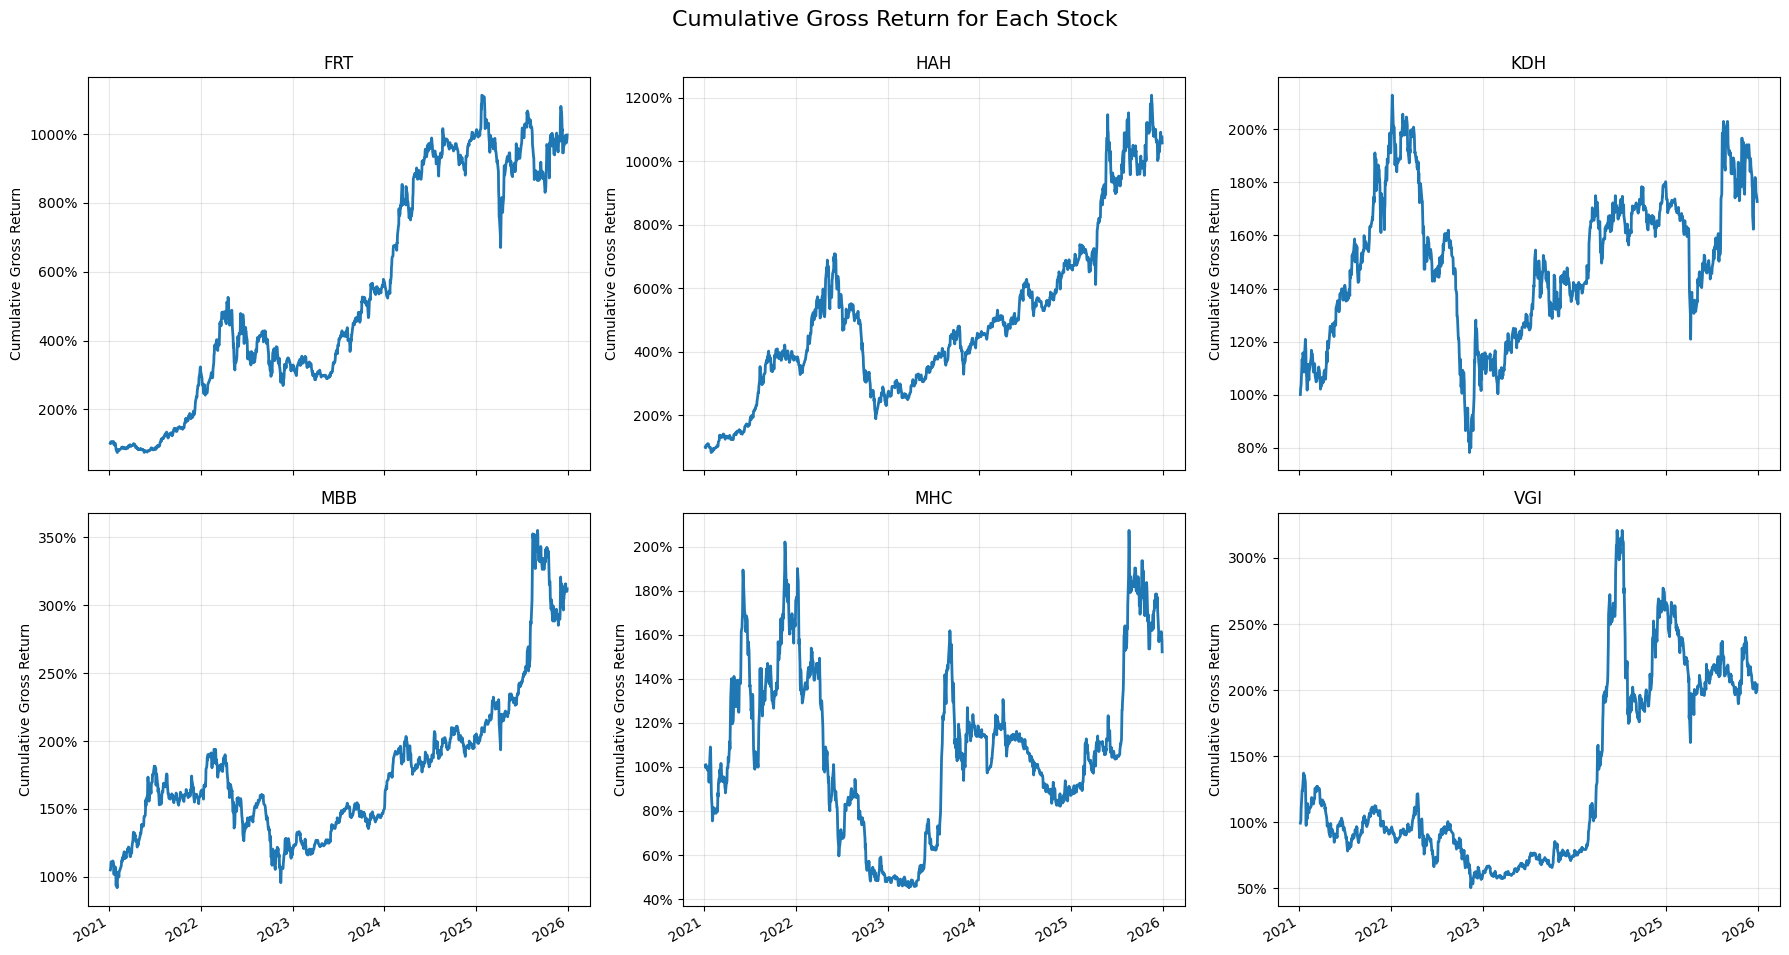

In [ ]:


# Vẽ biểu đồ cumulative gross cho từng cổ phiếu trong một bảng lớn

df_portfolio['gross_return'] = 1 + df_portfolio['ret_simple']
df_portfolio['cum_gross'] = df_portfolio.groupby(symbol_col)['gross_return'].cumprod()

symbols = sorted(df_portfolio[symbol_col].unique())
rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for i, symbol in enumerate(symbols):
    group = df_portfolio[df_portfolio[symbol_col] == symbol]
    axes[i].plot(group['Date'], group['cum_gross'], label=f'{symbol} cum gross', linewidth=2)
    axes[i].set_title(symbol)
    axes[i].set_ylabel('Cumulative Gross Return')
    axes[i].grid(alpha=0.3)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for j in range(len(symbols), len(axes)):
    fig.delaxes(axes[j])

fig.autofmt_xdate(rotation=30)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle('Cumulative Gross Return for Each Stock', fontsize=16)
plt.show()

In [35]:
# Factor modeling: build market factor, align returns, run OLS per stock
import os
import statsmodels.api as sm

# Build/locate market series (weekly)
market_series = None
vn_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao/output/VNINDEX.csv'
if os.path.exists(vn_path):
    VN = pd.read_csv(vn_path, index_col=0, parse_dates=True)
    vn_col = VN.columns[0]
    market_series = VN[vn_col].resample('W-FRI').last()
else:
    # check if VNINDEX present as a symbol in raw data
    if 'VNINDEX' in df_week2[symbol_col].unique():
        vn_df = df_week2[df_week2[symbol_col] == 'VNINDEX'].copy()
        vn_df['Date'] = pd.to_datetime(vn_df['Date'])
        market_series = vn_df.set_index('Date')['Close'].resample('W-FRI').last()
    else:
        # fallback: use average of available instrument weekly close as proxy
        market_series = data_weekly.mean(axis=1)

# Compute market weekly returns
market_weekly = market_series.pct_change()

# Weekly risk-free: prefer TBill if available
if 'TBill' in globals() and TBill is not None and 'rf_weekly' in TBill.columns:
    rf_weekly = TBill['rf_weekly'].resample('W-FRI').last().reindex(weekly_ret.index).fillna(method='ffill')
else:
    # approximate from annual R_f_annual
    R_f_annual = globals().get('R_f_annual', 0.05)
    rf_weekly = pd.Series((1 + R_f_annual) ** (1 / 52) - 1, index=weekly_ret.index)

# Build factor dataframe
df_factors = pd.DataFrame(index=weekly_ret.index)
df_factors['Market'] = market_weekly.reindex(df_factors.index)
df_factors['Market_Minus_Rf'] = df_factors['Market'] - rf_weekly

# Try to load SMB/HML if provided
ff_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao/output/FF_factors.csv'
if os.path.exists(ff_path):
    ff = pd.read_csv(ff_path, index_col=0, parse_dates=True)
    # Expect columns like SMB, HML, and maybe Market
    for c in ['SMB', 'HML']:
        if c in ff.columns:
            df_factors[c] = ff[c].reindex(df_factors.index)

print('Factors ready:')
print(df_factors.dropna().head())

# Run OLS per stock using excess returns (Ri - Rf)
results = {}
rows = []
for symbol in weekly_ret.columns:
    Y = weekly_ret[symbol].reindex(df_factors.index) - rf_weekly
    X_cols = ['Market_Minus_Rf']
    if 'SMB' in df_factors.columns:
        X_cols += ['SMB']
    if 'HML' in df_factors.columns:
        X_cols += ['HML']
    X = df_factors[X_cols].reindex(df_factors.index)
    X = sm.add_constant(X)
    mask = Y.notna() & X.notna().all(axis=1)
    if mask.sum() < 10:
        print(symbol, 'not enough observations for regression (n=', mask.sum(), ')')
        continue
    model = sm.OLS(Y[mask], X[mask]).fit()
    results[symbol] = model
    rows.append({
        'symbol': symbol,
        'alpha': model.params.get('const', np.nan),
        'beta_market': model.params.get('Market_Minus_Rf', np.nan),
        'R2': model.rsquared,
        'nobs': int(model.nobs)
    })

results_df = pd.DataFrame(rows).set_index('symbol')
print('\nRegression summary (key stats):')
print(results_df)

# Save detailed summaries if needed
model_summaries = {s: results[s].summary() for s in results}

Factors ready:
              Market  Market_Minus_Rf
Date                                 
2021-01-15  0.093968         0.093030
2021-01-22  0.005804         0.004865
2021-01-29 -0.149067        -0.150006
2021-02-05  0.022604         0.021665
2021-02-12 -0.016910        -0.017849

Regression summary (key stats):
           alpha  beta_market        R2  nobs
symbol                                       
FRT     0.003963     1.190441  0.630265   256
HAH     0.005215     0.851110  0.322270   256
KDH    -0.001675     0.752649  0.439058   256
MBB     0.001595     0.493432  0.221108   256
MHC     0.000287     0.700956  0.135224   256
VGI    -0.001715     1.090560  0.459228   256


In [38]:
# 3. Penalty methods: Ridge (L2) and Lasso (L1) with cross-validation
try:
    from sklearn.linear_model import RidgeCV, LassoCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline
except Exception as e:
    print('scikit-learn not available. Install with: pip install scikit-learn')
    raise

ridge_results = []
lasso_results = []
ridge_models = {}
lasso_models = {}

# Prepare factor matrix
X_full = df_factors.copy()
X_cols = [c for c in X_full.columns if c != 'Market']  # keep Market_Minus_Rf etc.
X_full = X_full[X_cols]

for symbol in weekly_ret.columns:
    y = weekly_ret[symbol].reindex(X_full.index) - rf_weekly
    X = X_full.reindex(y.index)
    mask = y.notna() & X.notna().all(axis=1)
    if mask.sum() < 10:
        print(symbol, 'skipped (insufficient data)')
        continue

    X_tr = X[mask]
    y_tr = y[mask]

    # Ridge with built-in CV over alphas
    alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
    ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))
    ridge.fit(X_tr, y_tr)
    ridge_coef = ridge.named_steps['ridgecv'].coef_
    ridge_alpha = ridge.named_steps['ridgecv'].alpha_
    ridge_score = ridge.score(X_tr, y_tr)
    ridge_results.append({'symbol': symbol, 'alpha': ridge_alpha, 'R2': ridge_score, 'nobs': int(mask.sum())})
    ridge_models[symbol] = {'model': ridge, 'coef': ridge_coef, 'features': X_tr.columns.tolist()}

    # Lasso with CV
    lasso = make_pipeline(StandardScaler(), LassoCV(alphas=None, cv=5, max_iter=5000))
    lasso.fit(X_tr, y_tr)
    lasso_coef = lasso.named_steps['lassocv'].coef_
    lasso_alpha = lasso.named_steps['lassocv'].alpha_
    lasso_score = lasso.score(X_tr, y_tr)
    n_nonzero = (lasso_coef != 0).sum()
    lasso_results.append({'symbol': symbol, 'alpha': lasso_alpha, 'R2': lasso_score, 'n_nonzero': int(n_nonzero), 'nobs': int(mask.sum())})
    lasso_models[symbol] = {'model': lasso, 'coef': lasso_coef, 'features': X_tr.columns.tolist()}

ridge_df = pd.DataFrame(ridge_results).set_index('symbol') if ridge_results else pd.DataFrame()
lasso_df = pd.DataFrame(lasso_results).set_index('symbol') if lasso_results else pd.DataFrame()

print('\nRidge summary:')
print(ridge_df)
print('\nLasso summary:')
print(lasso_df)

# Show selected (non-zero) factors per stock for Lasso
print('\nLasso selected factors (non-zero coefficients):')
for s, info in lasso_models.items():
    coefs = info['coef']
    feats = info['features']
    selected = [f for f, c in zip(feats, coefs) if abs(c) > 1e-8]
    print(s + ':', selected)

scikit-learn not available. Install with: pip install scikit-learn


ModuleNotFoundError: No module named 'sklearn'